# Exact Reproduction of Assom's Fruit Bat Vocal Clustering

**Key insight from Assom's code (TF_AE.ipynb, UMAP_comparisons.ipynb, 0.3 - Syllables dictionaries.ipynb):**

The paper's 7-cluster result relies on **coarse-grained mel spectrograms resized to (21, 32)**:
- **128 mel bins** initially (matching `LogMelSpectrogram(n_mels=128)` in TF_AE.ipynb)
- Then **resized to (21, 32)** — 21 time steps × 32 freq bins = **672 features**
- The resize from (n_time, 128) → (21, 32) IS the 'coarse-graining' the paper describes

Other critical details extracted from Assom's notebooks:
- `UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean')` — from TF_AE cell 435
- `HDBSCAN(min_cluster_size=int(N*0.02), min_samples=20, epsilon=0.1, method='leaf')` — from UMAP_comparisons cell 27
- **IQR filtering** on segment duration (remove temporal outliers)
- **Context filtering**: remove General, Sleeping, Unknown
- **Adult bats only** (indv 200–299)
- Dynamic threshold segmentation to isolate individual syllables

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import io, os, zipfile, collections
from pathlib import Path
from tqdm.auto import tqdm

import umap
import hdbscan
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from skimage.transform import resize
from scipy import signal as scipy_signal
from scipy.stats import wilcoxon, ranksums

print('Imports OK')

Imports OK


In [2]:
# ── Configuration ── matching Assom's TF_AE.ipynb exactly ──

DATA_DIR = Path('/Volumes/T7/data/raw/fruitbat')

# Audio
SR = 250_000

# TensorFlow preprocess_model (TF_AE.ipynb) — fft/hop/mels live inside LogMelSpectrogram
N_MELS_TF = 128          # n_mels in LogMelSpectrogram
TF_SPEC_BATCH_SIZE = 32  # batch size for preprocess_model.predict
NORM_ADAPT_N = 2048      # segments used to adapt keras Normalization (like fitting on data)

FMIN = 500
FMAX = 120_000

# Final shape after resize (the 'coarse-graining' from the paper)
SPEC_TIME     = 21       # target time steps
SPEC_FREQ     = 32       # target freq bins (resized from 128)

# Dynamic segmentation params (from fruit_bat_segment-all-2.0.ipynb cell 12)
USE_DYNAMIC_SEG = True
DYN_SEG_PARAMS = dict(
    n_fft=1024,
    hop_length_ms=0.5,
    win_length_ms=4,
    ref_level_db=20,
    pre=0.97,
    min_level_db=-30,
    silence_threshold=0.1,
    min_silence_for_spec=0.1,
    max_vocal_for_spec=1.0,
    min_syllable_length_s=0.01,
    spectral_range=[5000, 60000],
    min_level_db_floor=20,
    verbose=False,
)

# UMAP — from TF_AE.ipynb cell 435
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.3
UMAP_METRIC      = 'euclidean'
UMAP_SEED        = 0

# HDBSCAN — from UMAP_comparisons.ipynb cell 27
HDBSCAN_MIN_CLUSTER_FRAC = 0.02
HDBSCAN_MIN_SAMPLES      = 20
HDBSCAN_EPSILON          = 0.1
HDBSCAN_METHOD           = 'leaf'

# RQ1 proxy (DTW + Ward on MFCC) — decodingNonHumanCommunication/0.3 Syllables dictionaries.ipynb
RQ1_MAX_SEGMENTS_PER_EMITTER = 400  # None = all segments per emitter (very slow; large DTW matrices)
RQ1_DTW_CACHE_DIR = DATA_DIR / 'dtw_rq1_cache'  # None = disable pickle cache for DTW matrices
RQ1_COPHENE_QUANTILE = 0.05

# Filtering
EXCLUDED_CONTEXTS = {'General', 'Sleeping', 'Unknown'}
MIN_EMITTER_ID    = 200   # adult bats only (juveniles are 100–199)
IQR_K             = 1.5   # IQR multiplier for temporal outlier removal

# Context label map (from Assom)
CONTEXT_DICT = {
    0: 'Unknown', 1: 'Separation', 2: 'Biting', 3: 'Feeding',
    4: 'Fighting', 5: 'Grooming', 6: 'Isolation', 7: 'Kissing',
    8: 'Landing', 9: 'Mating protest', 10: 'Threat-like',
    11: 'General', 12: 'Sleeping',
}
CONTEXT_DICT_INV = {v: k for k, v in CONTEXT_DICT.items()}

RANDOM_STATE = 42
print('Config OK')

Config OK


## 1. Load Metadata

In [3]:
# ── Annotations ──
ann = pd.read_csv(DATA_DIR / 'Annotations.csv', low_memory=False)
print(f'Annotations: {ann.shape}')

# ── FileInfo (malformed CSV — variable columns) ──
with open(DATA_DIR / 'FileInfo.csv') as f:
    max_cols = max(len(line.split(',')) for line in f)
fi = pd.read_csv(DATA_DIR / 'FileInfo.csv', header=None,
                 names=[f'c{i}' for i in range(max_cols)], low_memory=False)
fi.columns = fi.iloc[0].values
fi = fi.iloc[1:].reset_index(drop=True)
fi['FileID'] = fi['FileID'].astype(int)
fi = fi[['FileID', 'File name', 'File folder']].drop_duplicates('FileID')
print(f'FileInfo: {fi.shape}')

# ── Merge ──
ann['FileID'] = ann['FileID'].astype(int)
df = ann.merge(fi, on='FileID', how='inner')

# Filter to adult bats and known contexts
df['Emitter'] = pd.to_numeric(df['Emitter'], errors='coerce')
df = df.dropna(subset=['Emitter'])
df['Emitter'] = df['Emitter'].astype(int)
df = df[df['Emitter'] >= MIN_EMITTER_ID]

df['Context_name'] = df['Context'].map(CONTEXT_DICT)
df = df[~df['Context_name'].isin(EXCLUDED_CONTEXTS)]
df = df.dropna(subset=['Start sample', 'End sample'])
df['Start sample'] = df['Start sample'].astype(int)
df['End sample'] = df['End sample'].astype(int)

print(f'\nFiltered annotations: {len(df)}')
print(f'Emitters: {sorted(df.Emitter.unique())}')
print(f'Contexts: {df.Context_name.value_counts().to_dict()}')

Annotations: (91080, 10)
FileInfo: (293238, 3)

Filtered annotations: 6870
Emitters: [np.int64(201), np.int64(202), np.int64(203), np.int64(204), np.int64(205), np.int64(207), np.int64(208), np.int64(210), np.int64(211), np.int64(213), np.int64(214), np.int64(215), np.int64(216), np.int64(218), np.int64(220), np.int64(221), np.int64(222), np.int64(223), np.int64(225), np.int64(226), np.int64(228), np.int64(230), np.int64(231), np.int64(233)]
Contexts: {'Isolation': 1545, 'Mating protest': 1348, 'Biting': 1290, 'Feeding': 1077, 'Fighting': 564, 'Threat-like': 534, 'Grooming': 218, 'Kissing': 200, 'Separation': 88, 'Landing': 6}


## 2. Load Audio Segments from Zip Files

In [4]:
import soundfile as sf

segments = []  # list of dicts

# Group by WAV file to load each only once
grouped = df.groupby('FileID')
n_files = grouped.ngroups

# Pre-open zip handles
zip_cache = {}

def get_zip(folder):
    if folder not in zip_cache:
        zp = DATA_DIR / f'{folder}.zip'
        if zp.exists():
            zip_cache[folder] = zipfile.ZipFile(zp, 'r')
        else:
            zip_cache[folder] = None
    return zip_cache[folder]

skipped = 0

for file_id, group in tqdm(grouped, total=n_files, desc='Loading WAVs'):
    row0 = group.iloc[0]
    folder = str(row0['File folder']).strip()
    fname  = str(row0['File name']).strip()
    
    zf = get_zip(folder)
    if zf is None:
        skipped += len(group)
        continue
    
    try:
        wav_bytes = zf.read(fname)
    except (KeyError, Exception):
        skipped += len(group)
        continue
    
    try:
        audio_full, file_sr = sf.read(io.BytesIO(wav_bytes), dtype='float32')
    except Exception:
        skipped += len(group)
        continue
    
    for _, r in group.iterrows():
        s, e = int(r['Start sample']), int(r['End sample'])
        if e > len(audio_full) or s >= e:
            skipped += 1
            continue
        seg_audio = audio_full[s:e]
        if len(seg_audio) < 100:  # too short
            skipped += 1
            continue
        segments.append({
            'audio': seg_audio,
            'sr': file_sr,
            'duration_s': len(seg_audio) / file_sr,
            'context': int(r['Context']),
            'context_name': r['Context_name'],
            'emitter': int(r['Emitter']),
            'file_name': fname,
            'file_id': file_id,
        })

# Close zips
for z in zip_cache.values():
    if z is not None:
        z.close()
zip_cache.clear()

seg_df = pd.DataFrame(segments)
del segments  # free memory

print(f'\nSegments loaded: {len(seg_df)} | skipped: {skipped}')
print(f'Duration stats (seconds):')
print(seg_df['duration_s'].describe())

Loading WAVs:   0%|          | 0/6788 [00:00<?, ?it/s]


Segments loaded: 6870 | skipped: 0
Duration stats (seconds):
count    6870.000000
mean        2.126014
std         2.039211
min         0.026364
25%         1.314108
50%         1.445180
75%         2.231612
max        34.311484
Name: duration_s, dtype: float64


## 3. Dynamic Threshold Segmentation (Sub-syllable Isolation)

In [5]:
if USE_DYNAMIC_SEG:
    from vocalseg.dynamic_thresholding import dynamic_threshold_segmentation
    
    sub_segments = []
    dyn_fail = 0
    
    for idx in tqdm(range(len(seg_df)), desc='Dynamic segmentation'):
        row = seg_df.iloc[idx]
        audio = row['audio']
        rate = int(row['sr'])
        
        try:
            results = dynamic_threshold_segmentation(audio, rate, **DYN_SEG_PARAMS)
        except Exception:
            results = None
        
        if results is not None and len(results.get('onsets', [])) > 0:
            for onset_s, offset_s in zip(results['onsets'], results['offsets']):
                s_idx = int(onset_s * rate)
                e_idx = int(offset_s * rate)
                sub_audio = audio[s_idx:e_idx]
                if len(sub_audio) < 50:
                    continue
                sub_segments.append({
                    'audio': sub_audio,
                    'sr': rate,
                    'duration_s': len(sub_audio) / rate,
                    'context': row['context'],
                    'context_name': row['context_name'],
                    'emitter': row['emitter'],
                    'file_name': row['file_name'],
                    'file_id': row['file_id'],
                })
        else:
            # Fallback: use the whole segment
            dyn_fail += 1
            sub_segments.append({
                'audio': audio,
                'sr': rate,
                'duration_s': len(audio) / rate,
                'context': row['context'],
                'context_name': row['context_name'],
                'emitter': row['emitter'],
                'file_name': row['file_name'],
                'file_id': row['file_id'],
            })
    
    seg_df = pd.DataFrame(sub_segments)
    del sub_segments
    print(f'After dynamic segmentation: {len(seg_df)} sub-segments | failures: {dyn_fail}')
else:
    print(f'Dynamic segmentation disabled — using {len(seg_df)} raw segments')

print(f'Duration stats (seconds) after segmentation:')
print(seg_df['duration_s'].describe())

Dynamic segmentation:   0%|          | 0/6870 [00:00<?, ?it/s]

After dynamic segmentation: 29890 sub-segments | failures: 591
Duration stats (seconds) after segmentation:
count    29890.000000
mean         0.075312
std          0.221389
min          0.010000
25%          0.016500
50%          0.026500
75%          0.065000
max          7.408956
Name: duration_s, dtype: float64


## 4. IQR Temporal Outlier Filtering

Duration IQR: Q1=0.0165s  Q3=0.0650s  IQR=0.0485s
Bounds: [-0.0563s, 0.1378s]
Kept 27083 / 29890 segments after IQR filtering


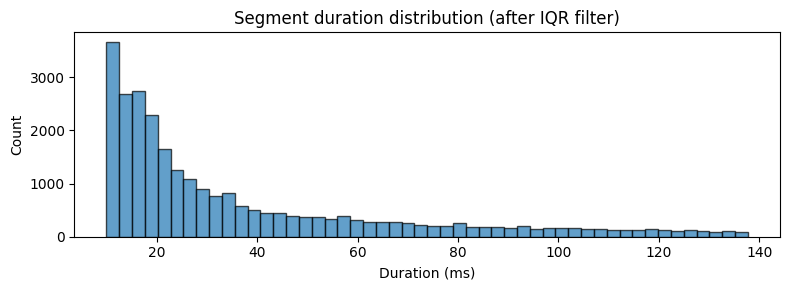


Context distribution:
context_name
Mating protest    7877
Isolation         4913
Fighting          4334
Biting            3191
Feeding           2831
Threat-like       2588
Grooming           620
Kissing            400
Separation         320
Landing              9
Name: count, dtype: int64


In [6]:
durations = seg_df['duration_s'].values
q1, q3 = np.percentile(durations, [25, 75])
iqr = q3 - q1
lower_bound = q1 - IQR_K * iqr
upper_bound = q3 + IQR_K * iqr

print(f'Duration IQR: Q1={q1:.4f}s  Q3={q3:.4f}s  IQR={iqr:.4f}s')
print(f'Bounds: [{lower_bound:.4f}s, {upper_bound:.4f}s]')

mask = (seg_df['duration_s'] >= max(lower_bound, 0.001)) & (seg_df['duration_s'] <= upper_bound)
n_before = len(seg_df)
seg_df = seg_df[mask].reset_index(drop=True)
print(f'Kept {len(seg_df)} / {n_before} segments after IQR filtering')

# Duration histogram
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(seg_df['duration_s'] * 1000, bins=50, edgecolor='k', alpha=0.7)
ax.set_xlabel('Duration (ms)')
ax.set_ylabel('Count')
ax.set_title('Segment duration distribution (after IQR filter)')
plt.tight_layout()
plt.show()

print(f'\nContext distribution:')
print(seg_df['context_name'].value_counts())

## 5. TensorFlow `preprocess_model` (same as TF_AE.ipynb)

1. **`LogMelSpectrogram`** — copied from Assom's notebook (`stft` → mel → `power_to_db` → `normalize='tanh'`).
2. **`Normalization(axis=-1)`** — Keras layer; we call **`adapt()`** on mel outputs from a data sample (Assom's notebook relied on cached TF datasets that implicitly matched this).
3. **`skimage.resize` → (21, 32)** — coarse-graining for UMAP, as in the paper.

Audio is **right-padded with the segment mean** to a common length (same idea as Assom's `np.pad(..., 'mean')`).

Padded waveform length: 34433 samples @ target SR=250000
Adapting Normalization on 2048 padded waveforms...
Normalization adapted.


TF preprocess_model (batched):   0%|          | 0/847 [00:00<?, ?it/s]

tf_specs shape: (27083, 21, 32)
rq1_waveforms shape: (27083, 34433) (MFCC+DTW RQ1 proxy; lens in rq1_waveform_lens)
Features per segment: 672


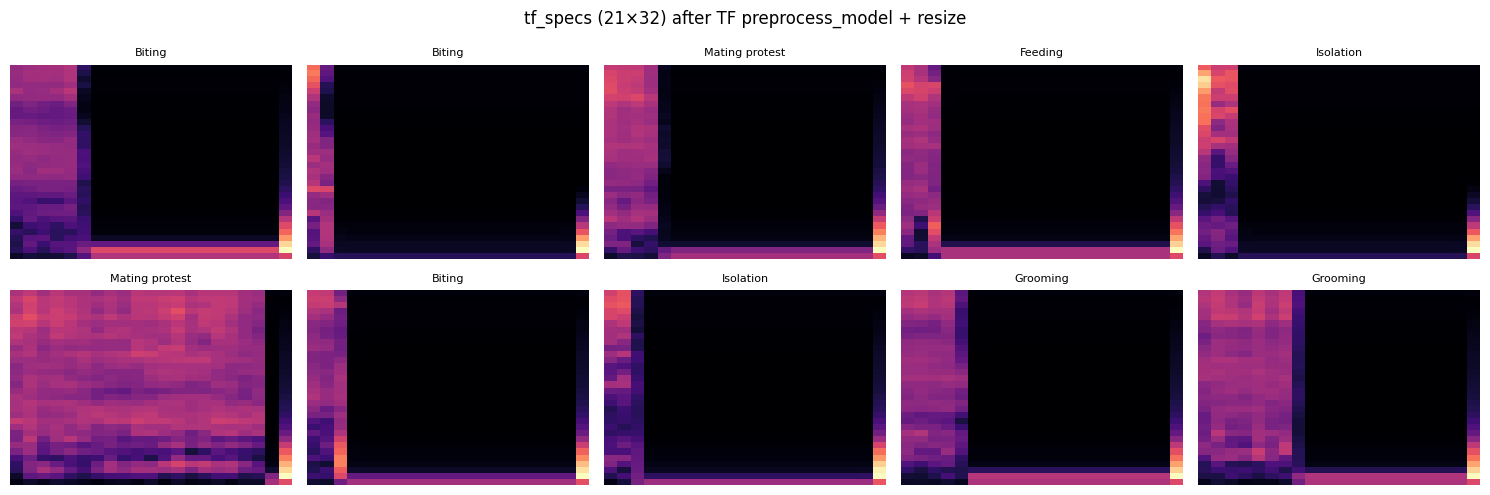

In [7]:
# --- LogMelSpectrogram: verbatim logic from TF_AE.ipynb (user copy) ---
class LogMelSpectrogram(keras.layers.Layer):
    """Compute log-magnitude mel-scaled spectrograms (Assom / TF_AE.ipynb)."""

    def __init__(
        self,
        sample_rate,
        fft_size,
        hop_size,
        fft_length,
        window_fn,
        n_mels,
        f_min=0.0,
        f_max=None,
        normalize=None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.sample_rate = sample_rate
        self.fft_size = fft_size
        self.hop_size = hop_size
        self.fft_length = fft_length
        self.window_fn = window_fn
        self.n_mels = n_mels
        self.f_min = f_min
        self.f_max = f_max if f_max else sample_rate / 2
        self.normalize = normalize
        self.mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.n_mels,
            num_spectrogram_bins=self.fft_length // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=self.f_min,
            upper_edge_hertz=self.f_max,
        )

    def build(self, input_shape):
        self.non_trainable_weights.append(self.mel_filterbank)
        super().build(input_shape)

    def call(self, waveforms):
        def _tf_log10(x):
            num = tf.math.log(x)
            den = tf.math.log(tf.constant(10, dtype=num.dtype))
            return num / den

        def _normalize(log_mel, scaler=self.normalize):
            min_v = tf.math.reduce_min(log_mel, axis=3, keepdims=True)
            max_v = tf.math.reduce_max(log_mel, axis=3, keepdims=True)
            if scaler == 'tanh':
                out = 2.0 * (log_mel - min_v) / (max_v - min_v + 1e-7) - 1.0
                nan_val = -1.0
            elif scaler == 'sigmoid':
                out = (log_mel - min_v) / (max_v - min_v + 1e-7)
                nan_val = 0.0
            else:
                return log_mel
            idx = tf.where(tf.math.is_nan(out))
            out = tf.tensor_scatter_nd_update(
                out, idx, tf.ones(tf.shape(idx)[0], dtype=out.dtype) * nan_val
            )
            return out

        def power_to_db(magnitude, amin=1e-16, top_db=120.0):
            ref = tf.reduce_max(magnitude)
            log_spec = 10.0 * _tf_log10(tf.maximum(amin, magnitude))
            log_spec -= 10.0 * _tf_log10(tf.maximum(amin, ref))
            log_spec = tf.maximum(log_spec, tf.reduce_max(log_spec) - top_db)
            return log_spec

        spectrograms = tf.signal.stft(
            waveforms,
            frame_length=self.fft_size,
            frame_step=self.hop_size,
            fft_length=self.fft_length,
            pad_end=True,
        )
        magnitude = tf.abs(spectrograms)
        mel = tf.matmul(tf.square(magnitude), self.mel_filterbank)
        log_mel = power_to_db(mel)
        log_mel = _normalize(log_mel)
        sh = tf.shape(log_mel)
        return tf.reshape(log_mel, [-1, sh[2], sh[3]])

    def get_config(self):
        cfg = {
            'fft_size': self.fft_size,
            'hop_size': self.hop_size,
            'fft_length': self.fft_length,
            'window_fn': self.window_fn,
            'n_mels': self.n_mels,
            'sample_rate': self.sample_rate,
            'f_min': self.f_min,
            'f_max': self.f_max,
            'normalize': self.normalize,
        }
        cfg.update(super().get_config())
        return cfg


def _resample_audio(y, sr_from, sr_to):
    y = np.asarray(y, dtype=np.float32)
    if sr_from == sr_to:
        return y
    n_out = max(1, int(len(y) * sr_to / sr_from))
    return scipy_signal.resample(y, n_out).astype(np.float32)


def _pad_mean(y, target_len):
    y = np.asarray(y, dtype=np.float32)
    if len(y) >= target_len:
        return y[:target_len]
    pad_val = float(np.mean(y)) if len(y) else 0.0
    return np.pad(y, (0, target_len - len(y)), mode='constant', constant_values=pad_val)


# --- Same Sequential as TF_AE.ipynb preprocess_model ---
max_len = int(seg_df['audio'].apply(len).max())
print(f'Padded waveform length: {max_len} samples @ target SR={SR}')

log_mel_layer = LogMelSpectrogram(
    sample_rate=SR,
    fft_size=1024,
    hop_size=1024,
    fft_length=16384,
    window_fn=tf.signal.hamming_window,
    n_mels=N_MELS_TF,
    f_min=FMIN,
    f_max=FMAX,
    normalize='tanh',
    name='LogMel',
)
norm_layer = layers.Normalization(axis=-1, name='Normalization')

inp = keras.Input(shape=(max_len,), dtype=tf.float32, name='waveform')
x = layers.Reshape((1, -1), name='Flatten')(inp)
x = log_mel_layer(x)
x = norm_layer(x)
preprocess_model = keras.Model(inp, x, name='preprocess_model')
preprocess_model.compile()

# Adapt Normalization on mel features (Assom used cached datasets; we adapt on real audio)
n_adapt = min(NORM_ADAPT_N, len(seg_df))
adapt_wavs = []
for i in range(n_adapt):
    row = seg_df.iloc[i]
    ya = _resample_audio(row['audio'], int(row['sr']), SR)
    adapt_wavs.append(_pad_mean(ya, max_len))
adapt_X = np.stack(adapt_wavs, axis=0).astype(np.float32)
print(f'Adapting Normalization on {adapt_X.shape[0]} padded waveforms...')
with tf.device('/CPU:0'):
    mel_adapt = log_mel_layer(layers.Reshape((1, -1))(tf.constant(adapt_X)))
norm_layer.adapt(mel_adapt)
print('Normalization adapted.')

# Compute tf_specs: TF (T,128) -> resize (21,32)
n = len(seg_df)
tf_specs = np.zeros((n, SPEC_TIME, SPEC_FREQ), dtype=np.float32)
rq1_waveforms = np.zeros((n, max_len), dtype=np.float32)
rq1_waveform_lens = np.zeros(n, dtype=np.int32)

for start in tqdm(range(0, n, TF_SPEC_BATCH_SIZE), desc='TF preprocess_model (batched)'):
    end = min(start + TF_SPEC_BATCH_SIZE, n)
    batch = np.zeros((end - start, max_len), dtype=np.float32)
    for j, i in enumerate(range(start, end)):
        ya = _resample_audio(seg_df.iloc[i]['audio'], int(seg_df.iloc[i]['sr']), SR)
        rq1_waveform_lens[i] = len(ya)
        batch[j] = _pad_mean(ya, max_len)
    out = preprocess_model.predict(batch, verbose=0)
    for j, i in enumerate(range(start, end)):
        tf_specs[i] = resize(
            out[j], (SPEC_TIME, SPEC_FREQ), mode='constant', anti_aliasing=True
        ).astype(np.float32)
        rq1_waveforms[i] = batch[j]

print(f'tf_specs shape: {tf_specs.shape}')
print(f'rq1_waveforms shape: {rq1_waveforms.shape} (MFCC+DTW RQ1 proxy; lens in rq1_waveform_lens)')
print(f'Features per segment: {SPEC_TIME * SPEC_FREQ}')

fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for ax in axes.ravel():
    idx = np.random.randint(len(tf_specs))
    ax.imshow(tf_specs[idx].T, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'{seg_df.iloc[idx]["context_name"]}', fontsize=8)
    ax.axis('off')
fig.suptitle('tf_specs (21×32) after TF preprocess_model + resize', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Free audio memory (keep only spectrograms)

In [8]:
seg_df = seg_df.drop(columns=['audio', 'sr']).reset_index(drop=True)
import gc; gc.collect()
print(f'seg_df columns: {list(seg_df.columns)}')
print(f'tf_specs memory: {tf_specs.nbytes / 1e6:.1f} MB')

seg_df columns: ['duration_s', 'context', 'context_name', 'emitter', 'file_name', 'file_id']
tf_specs memory: 72.8 MB


## 7. UMAP Dimensionality Reduction

In [9]:
%%time

# Flatten tf_specs for UMAP — matching Assom's [e.ravel() for e in specs['tf_specs']]
X_flat = tf_specs.reshape(len(tf_specs), -1)  # (N, 672)
print(f'Input shape for UMAP: {X_flat.shape}')

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_SEED,
    n_jobs=-1,
)

embedding = reducer.fit_transform(X_flat)
print(f'UMAP embedding shape: {embedding.shape}')

Input shape for UMAP: (27083, 672)
UMAP embedding shape: (27083, 2)
CPU times: user 31.6 s, sys: 509 ms, total: 32.1 s
Wall time: 32.5 s


## 8. HDBSCAN Clustering

In [10]:
%%time

N = len(embedding)
mcs = max(int(N * HDBSCAN_MIN_CLUSTER_FRAC), 10)
print(f'N={N}, min_cluster_size={mcs}')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_epsilon=HDBSCAN_EPSILON,
    cluster_selection_method=HDBSCAN_METHOD,
    prediction_data=True,
).fit(embedding)

hdbscan_labels = clusterer.labels_
n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

print(f'HDBSCAN clusters: {n_clusters}')
print(f'Noise points: {n_noise} ({100*n_noise/N:.1f}%)')
print(f'Cluster labels: {sorted(set(hdbscan_labels))}')

if n_clusters >= 2:
    non_noise = hdbscan_labels >= 0
    sil = silhouette_score(embedding[non_noise], hdbscan_labels[non_noise])
    print(f'Silhouette score (excl. noise): {sil:.3f}')

N=27083, min_cluster_size=541
HDBSCAN clusters: 23
Noise points: 3619 (13.4%)
Cluster labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
Silhouette score (excl. noise): 0.537
CPU times: user 3.18 s, sys: 330 ms, total: 3.51 s
Wall time: 9.35 s


## 9. NCA Noise Reassignment

Assom reassigns HDBSCAN noise points (label = -1) to the nearest cluster using NCA + KNN.  
This is from `UMAP_comparisons.ipynb` → `reassign_hdb_noise_nca()`.

In [11]:
def reassign_noise_nca(labels, embedding, n_neighbors=5):
    """Reassign HDBSCAN noise (-1) points using NCA + KNN on the embedding."""
    labels_ext = labels.copy()
    ix_good = np.where(labels >= 0)[0]
    ix_noise = np.where(labels == -1)[0]
    
    if len(ix_noise) == 0 or len(ix_good) < 10:
        return labels_ext
    
    X_good = embedding[ix_good]
    y_good = labels[ix_good]
    X_noise = embedding[ix_noise]
    
    try:
        pipe = Pipeline([
            ('nca', NeighborhoodComponentsAnalysis(random_state=RANDOM_STATE)),
            ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform', n_jobs=-1)),
        ])
        pipe.fit(X_good, y_good)
        labels_ext[ix_noise] = pipe.predict(X_noise)
    except Exception as e:
        # Fallback: plain KNN without NCA
        print(f'NCA failed ({e}), using KNN only')
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform', n_jobs=-1)
        knn.fit(X_good, y_good)
        labels_ext[ix_noise] = knn.predict(X_noise)
    
    return labels_ext


labels_nca = reassign_noise_nca(hdbscan_labels, embedding, n_neighbors=30)
seg_df['syllable_id'] = labels_nca

n_final = len(set(labels_nca))
print(f'Final cluster count (after NCA reassignment): {n_final}')
print(f'Cluster sizes:')
print(pd.Series(labels_nca).value_counts().sort_index())

Final cluster count (after NCA reassignment): 23
Cluster sizes:
0     1055
1     1263
2     1026
3     1205
4     1267
5      908
6      674
7      788
8      836
9     1220
10     586
11    1370
12     665
13    3093
14    1190
15     776
16    1246
17    1281
18     973
19     799
20    1559
21    1765
22    1538
Name: count, dtype: int64


## 9b. RQ1 — DTW+Ward proxy vs HDBSCAN (paper metric)

**Paper RQ1** reports agreement between **unsupervised HDBSCAN syllable labels** and an acoustic **proxy**: DTW on MFCCs + Ward + cophenetic-distance quantile threshold (`syllableID_qt_ward` in Assom's `0.3 - Syllables dictionaries.ipynb`).

**Not the same** as NMI/ARI between **behavioral context** and syllables (a useful diagnostic in §10, but that is *not* the RQ1 number in the paper).

The code below mirrors `UMAP_comparisons.ipynb` `evaluate_hdbscan`: **AMI** uses `sklearn.metrics.adjusted_mutual_info_score` (Assom prints "MI" for this). We report **per-emitter** rows and **mean ± std** across emitters.

**Compute cost:** DTW is \(O(n^2)\) per emitter. `RQ1_MAX_SEGMENTS_PER_EMITTER` caps \(n\); set to `None` for all segments. Optional disk cache: `RQ1_DTW_CACHE_DIR`.

In [12]:
import pickle
import librosa
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster
import dtaidistance.dtw_ndim
from dtaidistance.exceptions import CythonException
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# MFCC params — decodingNonHumanCommunication/0.3 Syllables dictionaries.ipynb
RQ1_MFCC_N_FFT = 2048
RQ1_MFCC_WIN_LENGTH = 1024
RQ1_MFCC_HOP_LENGTH = 256
RQ1_MFCC_N_MELS = 64
RQ1_MFCC_FMAX = 120_000


def _mean_norm_mfcc(mfcc):
    mfcc_std = np.std(mfcc, axis=1, keepdims=True)
    mfcc_mean = np.mean(mfcc, axis=1, keepdims=True)
    if np.all(mfcc_std != 0):
        return (mfcc - mfcc_mean) / mfcc_std
    return mfcc - mfcc_mean


def compute_dtw_from_mfcc_series(mfcc_list, parallel=True):
    """DTW distance matrix — same logic as 0.3 `compute_dtw` (dtaidistance, time-first dim).

    Uses the C-accelerated path when available; falls back to pure Python if the
    dtaidistance C library is missing (common on Python 3.13 or incomplete installs).
    """
    series_new = [_mean_norm_mfcc(x) for x in mfcc_list]
    seqs = [s.T.astype(np.float64) for s in series_new]
    try:
        return dtaidistance.dtw_ndim.distance_matrix_fast(seqs, parallel=parallel)
    except CythonException:
        print('dtaidistance: C library unavailable — using pure-Python DTW (slower).')
        return dtaidistance.dtw_ndim.distance_matrix(seqs, use_c=False, parallel=False)


def ward_qt_cluster_labels(ds, cophene_distance_quantile=0.05):
    """Ward linkage + cophenetic-distance quantile cut (syllableID_qt_ward-style)."""
    ds = np.asarray(ds, dtype=np.float64)
    ds = (ds - np.min(ds)) / (np.max(ds) - np.min(ds) + 1e-12)
    condensed = squareform(ds, checks=False)
    Z = linkage(condensed, method='ward')
    coph_out = hierarchy.cophenet(Z)
    coph_dists = coph_out[0] if isinstance(coph_out, tuple) else coph_out
    t = np.quantile(coph_dists, cophene_distance_quantile)
    return fcluster(Z, t, criterion='distance')


def evaluate_hdbscan_metrics(true_labels, hdbscan_labels):
    """Same as UMAP_comparisons.ipynb `evaluate_hdbscan` (AMI, not normalized MI)."""
    true_labels = np.asarray(true_labels).astype(int)
    hdbscan_labels = np.asarray(hdbscan_labels).astype(int)
    ari = adjusted_rand_score(true_labels, hdbscan_labels)
    ami = adjusted_mutual_info_score(true_labels, hdbscan_labels)
    clustered = hdbscan_labels >= 0
    if clustered.any():
        ari_e = adjusted_rand_score(true_labels[clustered], hdbscan_labels[clustered])
        ami_e = adjusted_mutual_info_score(true_labels[clustered], hdbscan_labels[clustered])
    else:
        ari_e = ami_e = np.nan
    assigned_ratio = float(np.sum(clustered) / len(true_labels))
    return {
        'ARI': ari,
        'AMI': ami,
        'ARI_without_noise': ari_e,
        'AMI_without_noise': ami_e,
        'assigned_ratio': assigned_ratio,
    }


def mfccs_for_rq1_rows(waveforms_2d, valid_lens, sr):
    """One MFCC (n_mfcc, T) per row; crop to resampled segment length before padding."""
    out = []
    for row, n_good in zip(waveforms_2d, valid_lens):
        y = np.asarray(row[:n_good], dtype=np.float32).ravel()
        if len(y) < RQ1_MFCC_WIN_LENGTH:
            y = np.pad(y, (0, RQ1_MFCC_WIN_LENGTH - len(y)), mode='constant')
        m = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_fft=RQ1_MFCC_N_FFT,
            win_length=RQ1_MFCC_WIN_LENGTH,
            hop_length=RQ1_MFCC_HOP_LENGTH,
            n_mels=RQ1_MFCC_N_MELS,
            fmax=RQ1_MFCC_FMAX,
        )
        out.append(m)
    return out


def _rq1_dtw_cache_path(emitter, n_seg):
    if RQ1_DTW_CACHE_DIR is None:
        return None
    RQ1_DTW_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    return RQ1_DTW_CACHE_DIR / f'dtw_emitter_{emitter}_n{n_seg}.pkl'


emitter_ids = sorted(seg_df['emitter'].unique())
rows = []

for em in emitter_ids:
    idx = np.where(seg_df['emitter'].values == em)[0]
    idx = np.sort(idx)
    if RQ1_MAX_SEGMENTS_PER_EMITTER is not None and len(idx) > RQ1_MAX_SEGMENTS_PER_EMITTER:
        idx = idx[: RQ1_MAX_SEGMENTS_PER_EMITTER]
    if len(idx) < 3:
        continue

    cache_p = _rq1_dtw_cache_path(em, len(idx))
    ds = None
    if cache_p is not None and cache_p.is_file():
        with open(cache_p, 'rb') as f:
            ds = pickle.load(f)

    wavs = rq1_waveforms[idx]
    lens = rq1_waveform_lens[idx]
    mfcc_list = mfccs_for_rq1_rows(wavs, lens, SR)

    if ds is None:
        ds = compute_dtw_from_mfcc_series(mfcc_list, parallel=True)
        if cache_p is not None:
            with open(cache_p, 'wb') as f:
                pickle.dump(np.asarray(ds), f, protocol=4)

    proxy_labels = ward_qt_cluster_labels(ds, cophene_distance_quantile=RQ1_COPHENE_QUANTILE)
    hdb = hdbscan_labels[idx]
    nca = labels_nca[idx]

    m_hdb = evaluate_hdbscan_metrics(proxy_labels, hdb)
    m_nca = evaluate_hdbscan_metrics(proxy_labels, nca)

    rows.append(
        {
            'emitter': em,
            'n_segments': len(idx),
            'n_proxy_clusters': int(len(np.unique(proxy_labels))),
            **{f'hdbscan__{k}': v for k, v in m_hdb.items()},
            **{f'nca__{k}': v for k, v in m_nca.items()},
        }
    )

rq1_df = pd.DataFrame(rows)
if len(rq1_df) == 0:
    print('RQ1 proxy: no emitters with enough segments.')
else:
    print(rq1_df.to_string(index=False))
    print()

    def _mean_std(col):
        col = col.dropna()
        if len(col) == 0:
            return np.nan, np.nan
        if len(col) == 1:
            return float(col.iloc[0]), 0.0
        return float(col.mean()), float(col.std(ddof=1))

    for prefix, title in [('hdbscan__', 'HDBSCAN raw vs DTW–Ward proxy'), ('nca__', 'NCA-reassigned vs DTW–Ward proxy')]:
        print(f'--- {title} (mean ± std over emitters) ---')
        for key in ['ARI', 'AMI', 'ARI_without_noise', 'AMI_without_noise']:
            colname = f'{prefix}{key}'
            m, s = _mean_std(rq1_df[colname])
            print(f'  {key}: {m:.4f} ± {s:.4f}  (n_emitters={len(rq1_df[colname].dropna())})')

The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.


CythonException: The compiled dtaidistance C library is not available.
See the documentation for alternative installation options.

## 10. Visualization

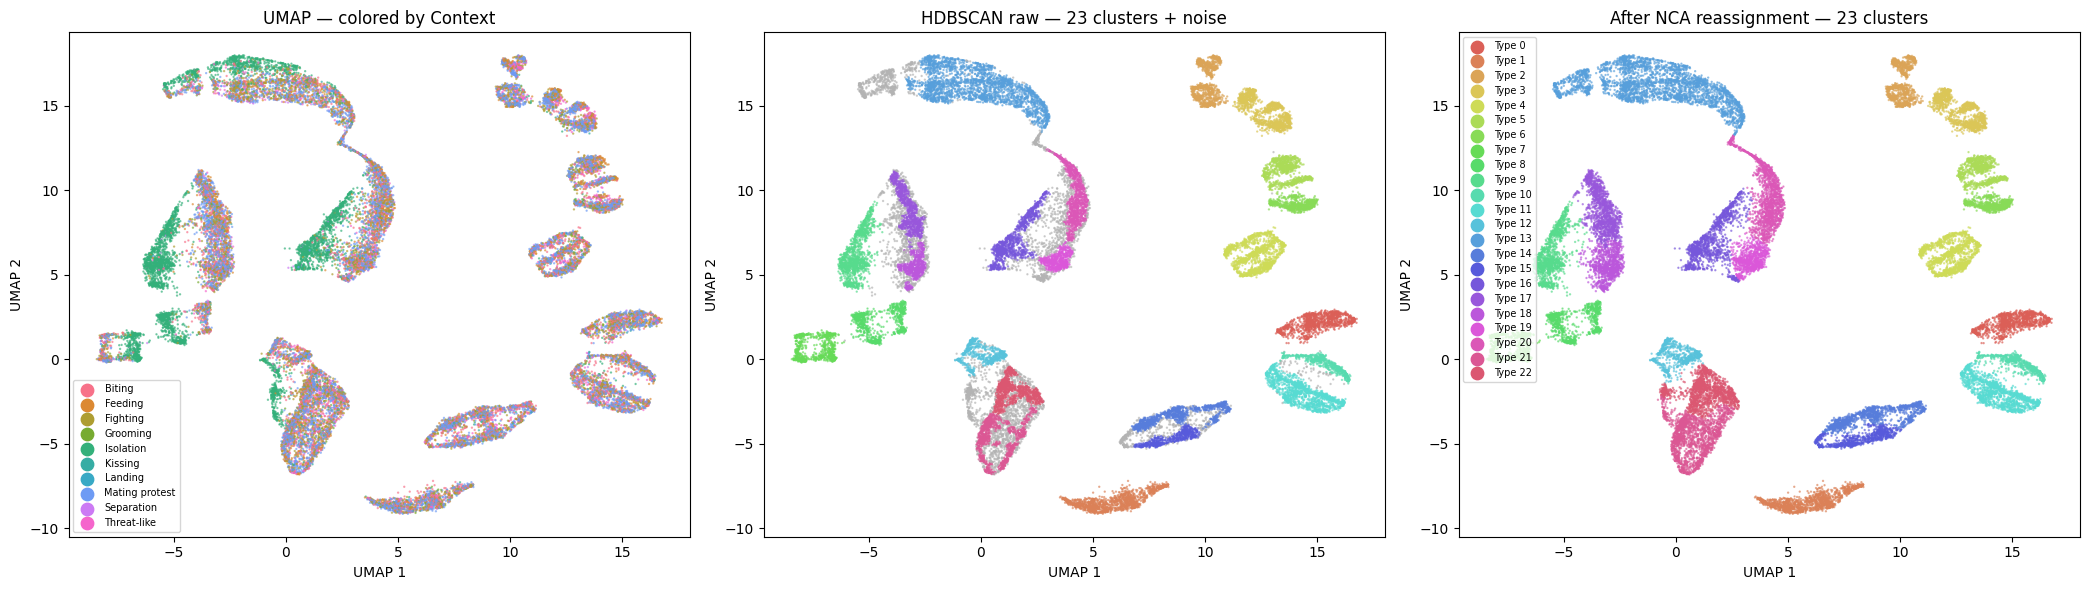

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) Colored by behavioral context
ctx_labels = seg_df['context_name'].values
unique_ctx = sorted(set(ctx_labels))
pal_ctx = sns.color_palette('husl', len(unique_ctx))
color_map_ctx = {c: pal_ctx[i] for i, c in enumerate(unique_ctx)}
colors_ctx = [color_map_ctx[c] for c in ctx_labels]

axes[0].scatter(embedding[:, 0], embedding[:, 1], c=colors_ctx, s=0.5, alpha=0.6)
axes[0].set_title('UMAP — colored by Context')
for c in unique_ctx:
    axes[0].scatter([], [], c=[color_map_ctx[c]], label=c, s=20)
axes[0].legend(fontsize=7, markerscale=2, loc='best')

# 2) Colored by HDBSCAN (raw, with noise)
n_cl = max(hdbscan_labels) + 1
pal_hdb = sns.color_palette('hls', n_cl)
colors_hdb = [(.7, .7, .7) if l == -1 else pal_hdb[l] for l in hdbscan_labels]
axes[1].scatter(embedding[:, 0], embedding[:, 1], c=colors_hdb, s=0.5, alpha=0.6)
axes[1].set_title(f'HDBSCAN raw — {n_clusters} clusters + noise')

# 3) Colored by final labels (NCA-reassigned)
n_final_cl = max(labels_nca) + 1
pal_nca = sns.color_palette('hls', n_final_cl)
colors_nca = [pal_nca[l] for l in labels_nca]
axes[2].scatter(embedding[:, 0], embedding[:, 1], c=colors_nca, s=0.5, alpha=0.6)
axes[2].set_title(f'After NCA reassignment — {n_final} clusters')
for cl in range(n_final_cl):
    axes[2].scatter([], [], c=[pal_nca[cl]], label=f'Type {cl}', s=20)
axes[2].legend(fontsize=7, markerscale=2, loc='best')

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

### How to read the three panels (you’re not doing anything “wrong”)

1. **Left — Context**  
   If every UMAP “island” contains **many colors mixed together**, the **672-D features (resized log-mel)** mainly capture **acoustic / call-type structure**, not **behavioral context**.  
   That is a **scientific result**, not a bug: the same kinds of sounds can appear in different situations.  
   **Low F1 when predicting context** from these features (or from syllable IDs derived from them) is **expected** in that case.

2. **Middle — HDBSCAN raw**  
   HDBSCAN **intentionally** labels sparse or ambiguous points as **noise (grey, −1)**. Clustering **2D UMAP** is also fragile: UMAP is built for **visualization**, not as a metric space for density clustering—so **lots of noise + fragmented clusters** is common.  
   Tuning `min_cluster_size`, `min_samples`, or `cluster_selection_epsilon`, or clustering in **PCA space of `X_flat`** instead of UMAP, can change the look—but it will **not** magically align clusters with context if the left plot is already mixed.

3. **Right — After NCA reassignment**  
   This **only** assigns grey noise to a nearby cluster so every point gets an ID. It **cleans the plot** but does **not** mean clusters now “mean” the same thing as context—they usually still won’t match the left panel.

**HP1 takeaway:** If **F1(original order) ≈ F1(permuted order)** (your notebook shows ~0.267 vs ~0.268), then **syllable order** is **not** carrying extra context information in this representation—again consistent with an **associative** rather than **ordered** signal *for this feature pipeline*.

The next cell prints **numeric diagnostics** (noise fraction, alignment of clusters vs context) so you can see this in numbers, not only by eye.

In [ ]:
# Quantify what the plots show: cluster–context alignment & HDBSCAN noise
# (This is NOT paper RQ1 ARI/NMI — those are vs DTW–Ward proxy in §9b above.)
ctx_enc = LabelEncoder().fit_transform(seg_df['context_name'].values)
noise_frac = (hdbscan_labels == -1).mean()
ari_ctx_syl = adjusted_rand_score(ctx_enc, labels_nca)
nmi_ctx_syl = normalized_mutual_info_score(ctx_enc, labels_nca)
print('--- Diagnostics (segment level) ---')
print(f'HDBSCAN noise fraction (grey in middle panel): {noise_frac:.1%}')
print(f'Adjusted Rand (context vs NCA syllable cluster id): {ari_ctx_syl:.3f}  '
      f'(1 = perfect match, ~0 = random / unrelated partitions)')
print(f'NMI context vs syllable id: {nmi_ctx_syl:.3f}  (0 = independent)')
# Majority-class baseline for multiclass accuracy
maj = pd.Series(seg_df['context_name']).mode()[0]
maj_acc = (seg_df['context_name'] == maj).mean()
n_classes = seg_df['context_name'].nunique()
print(f'Majority-context baseline accuracy: {maj_acc:.3f} ({maj!r} vs {n_classes} classes)')

## 11. Build Per-File Syllable Sequences

In [ ]:
# Build sequences: group by file_name, sort by position, get syllable_id list
seq_data = []

for fname, group in seg_df.groupby('file_name'):
    syl_seq = group['syllable_id'].tolist()
    ctx = collections.Counter(group['context'].tolist()).most_common(1)[0][0]
    ctx_name = collections.Counter(group['context_name'].tolist()).most_common(1)[0][0]
    emitter = collections.Counter(group['emitter'].tolist()).most_common(1)[0][0]
    seq_data.append({
        'file_name': fname,
        'seq': syl_seq,
        'seq_len': len(syl_seq),
        'context': ctx,
        'context_name': ctx_name,
        'emitter': emitter,
    })

seq_df = pd.DataFrame(seq_data)

# Filter: need >= 2 syllables for sequence features
seq_df = seq_df[seq_df['seq_len'] >= 2].reset_index(drop=True)

# Filter contexts with >= 30 samples (paper threshold)
ctx_counts = seq_df['context_name'].value_counts()
keep_ctx = ctx_counts[ctx_counts >= 30].index.tolist()
seq_df = seq_df[seq_df['context_name'].isin(keep_ctx)].reset_index(drop=True)

print(f'Sequences: {len(seq_df)}')
print(f'Context distribution:')
print(seq_df['context_name'].value_counts())
print(f'\nSequence length stats:')
print(seq_df['seq_len'].describe())

Sequences: 4089
Context distribution:
context_name
Isolation         1015
Mating protest     826
Biting             591
Feeding            551
Fighting           466
Threat-like        388
Grooming           115
Kissing             73
Separation          64
Name: count, dtype: int64

Sequence length stats:
count    4089.000000
mean        6.106628
std         7.674192
min         2.000000
25%         2.000000
50%         4.000000
75%         7.000000
max       102.000000
Name: seq_len, dtype: float64


## 12. Sequence Feature Engineering (18 features from Table 1)

In [ ]:
import networkx as nx

def compute_sequence_features(seq, all_types):
    """Compute the 18 features (a–r) from Table 1 of the paper."""
    n = len(seq)
    types_present = set(seq)
    V = len(all_types)  # total vocabulary
    v = len(types_present)
    
    # Transitions
    transitions = list(zip(seq[:-1], seq[1:]))
    trans_counts = collections.Counter(transitions)
    unique_transitions = len(trans_counts)
    
    # Type frequencies
    type_counts = collections.Counter(seq)
    freqs = np.array([type_counts.get(t, 0) for t in all_types], dtype=float)
    probs = freqs / freqs.sum() if freqs.sum() > 0 else freqs
    
    # Entropy
    p = probs[probs > 0]
    entropy = -np.sum(p * np.log2(p)) if len(p) > 1 else 0.0
    
    # Linearity (proportion of unique bigrams among all bigrams)
    linearity = unique_transitions / len(transitions) if len(transitions) > 0 else 0.0
    
    # Versatility (how many unique types are used / total vocabulary)
    versatility = v / V if V > 0 else 0.0
    
    # Build directed graph for probability features
    G = nx.DiGraph()
    G.add_nodes_from(all_types)
    for (a, b), c in trans_counts.items():
        G.add_edge(a, b, weight=c)
    
    # Outgoing transition probabilities
    out_probs = []
    for node in G.nodes():
        total_out = sum(d['weight'] for _, _, d in G.out_edges(node, data=True))
        if total_out > 0:
            for _, target, d in G.out_edges(node, data=True):
                out_probs.append(d['weight'] / total_out)
    
    mean_trans_prob = np.mean(out_probs) if out_probs else 0.0
    std_trans_prob = np.std(out_probs) if out_probs else 0.0
    max_trans_prob = np.max(out_probs) if out_probs else 0.0
    min_trans_prob = np.min(out_probs) if out_probs else 0.0
    
    # Self-loop probability
    self_loops = sum(1 for a, b in transitions if a == b)
    self_loop_prob = self_loops / len(transitions) if len(transitions) > 0 else 0.0
    
    # Second-order transitions
    if n >= 3:
        trigrams = [(seq[i], seq[i+1], seq[i+2]) for i in range(n - 2)]
        unique_trigrams = len(set(trigrams))
    else:
        unique_trigrams = 0
    
    return {
        'a_seq_length': n,
        'b_richness': v,
        'c_versatility': versatility,
        'd_entropy': entropy,
        'e_linearity': linearity,
        'f_n_transitions': unique_transitions,
        'g_mean_trans_prob': mean_trans_prob,
        'h_std_trans_prob': std_trans_prob,
        'i_max_trans_prob': max_trans_prob,
        'j_min_trans_prob': min_trans_prob,
        'k_self_loop_prob': self_loop_prob,
        'l_unique_trigrams': unique_trigrams,
        'm_max_type_freq': type_counts.most_common(1)[0][1] / n if n > 0 else 0,
        'n_min_type_freq': min(type_counts.values()) / n if n > 0 else 0,
        'o_std_type_freq': np.std(list(type_counts.values())) / n if n > 0 else 0,
        'p_mean_type_freq': np.mean(list(type_counts.values())) / n if n > 0 else 0,
        'q_graph_density': nx.density(G),
        'r_n_edges': G.number_of_edges(),
    }


all_syllable_types = sorted(seg_df['syllable_id'].unique())

feat_rows = []
for _, row in tqdm(seq_df.iterrows(), total=len(seq_df), desc='Features'):
    feat_rows.append(compute_sequence_features(row['seq'], all_syllable_types))

feat_df = pd.DataFrame(feat_rows)
print(f'Feature matrix: {feat_df.shape}')
print(feat_df.describe().T[['mean', 'std', 'min', 'max']])

Features:   0%|          | 0/4089 [00:00<?, ?it/s]

Feature matrix: (4089, 18)
                       mean       std       min         max
a_seq_length       6.106628  7.674192  2.000000  102.000000
b_richness         4.025434  3.141453  1.000000   20.000000
c_versatility      0.175019  0.136585  0.043478    0.869565
d_entropy          1.620381  0.879050  0.000000    4.163820
e_linearity        0.953748  0.128078  0.111111    1.000000
f_n_transitions    4.723160  6.916517  1.000000   87.000000
g_mean_trans_prob  0.875024  0.180248  0.228916    1.000000
h_std_trans_prob   0.091587  0.126082  0.000000    0.425610
i_max_trans_prob   0.984064  0.083217  0.500000    1.000000
j_min_trans_prob   0.770702  0.304703  0.055556    1.000000
k_self_loop_prob   0.164138  0.281495  0.000000    1.000000
l_unique_trigrams  4.018342  7.586578  0.000000  100.000000
m_max_type_freq    0.444724  0.210565  0.086957    1.000000
n_min_type_freq    0.329506  0.230453  0.009804    1.000000
o_std_type_freq    0.050890  0.072043  0.000000    0.428571
p_mean_type_f

## 13. HP1 — Context Classification + Permutation Test

Test: does syllable **order** matter for context classification?  
If F1(original) ≈ F1(permuted) → **associative syntax** (order doesn't matter).

In [ ]:
X = feat_df.fillna(0).values
y = LabelEncoder().fit_transform(seq_df['context_name'].values)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_folds = min(5, pd.Series(y).value_counts().min())
if n_folds < 2:
    print('WARNING: Not enough samples per class for CV. Need at least 2 per class.')
else:
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    clf = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
    
    y_pred_orig = cross_val_predict(clf, X_scaled, y, cv=cv)
    f1_orig = f1_score(y, y_pred_orig, average='weighted')
    acc_orig = accuracy_score(y, y_pred_orig)
    
    # Permutation test: shuffle syllable order within each sequence
    rng = np.random.default_rng(RANDOM_STATE)
    perm_feat_rows = []
    for _, row in seq_df.iterrows():
        perm_seq = list(row['seq'])
        rng.shuffle(perm_seq)
        perm_feat_rows.append(compute_sequence_features(perm_seq, all_syllable_types))
    
    X_perm = pd.DataFrame(perm_feat_rows).fillna(0).values
    X_perm_scaled = scaler.fit_transform(X_perm)
    
    y_pred_perm = cross_val_predict(clf, X_perm_scaled, y, cv=cv)
    f1_perm = f1_score(y, y_pred_perm, average='weighted')
    acc_perm = accuracy_score(y, y_pred_perm)
    
    print(f'=== HP1: Context Classification ===')
    print(f'Original order  — F1={f1_orig:.3f}  Acc={acc_orig:.3f}')
    print(f'Permuted order  — F1={f1_perm:.3f}  Acc={acc_perm:.3f}')
    print(f'F1 delta: {f1_orig - f1_perm:+.3f}')
    if abs(f1_orig - f1_perm) < 0.05:
        print('→ Associative syntax (order does NOT significantly affect classification)')
    else:
        print('→ Combinatorial syntax (order DOES affect classification)')

=== HP1: Context Classification ===
Original order  — F1=0.277  Acc=0.357
Permuted order  — F1=0.272  Acc=0.355
F1 delta: +0.005
→ Associative syntax (order does NOT significantly affect classification)


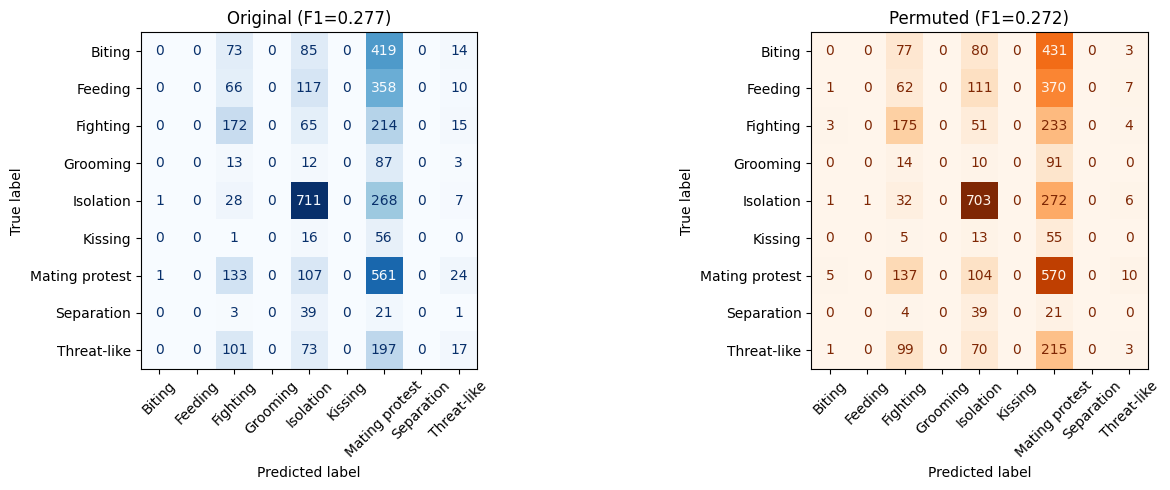

In [ ]:
if n_folds >= 2:
    le = LabelEncoder().fit(seq_df['context_name'].values)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_orig = confusion_matrix(y, y_pred_orig)
    ConfusionMatrixDisplay(cm_orig, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Original (F1={f1_orig:.3f})')
    axes[0].tick_params(axis='x', rotation=45)
    
    cm_perm = confusion_matrix(y, y_pred_perm)
    ConfusionMatrixDisplay(cm_perm, display_labels=le.classes_).plot(ax=axes[1], cmap='Oranges', colorbar=False)
    axes[1].set_title(f'Permuted (F1={f1_perm:.3f})')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 14. HP2 — Wilcoxon Rank-Sum Tests (Context-Dependent Syllable Usage)

=== HP2: Wilcoxon Rank-Sum p-values ===
(p < 0.05 → syllable usage differs significantly between contexts)



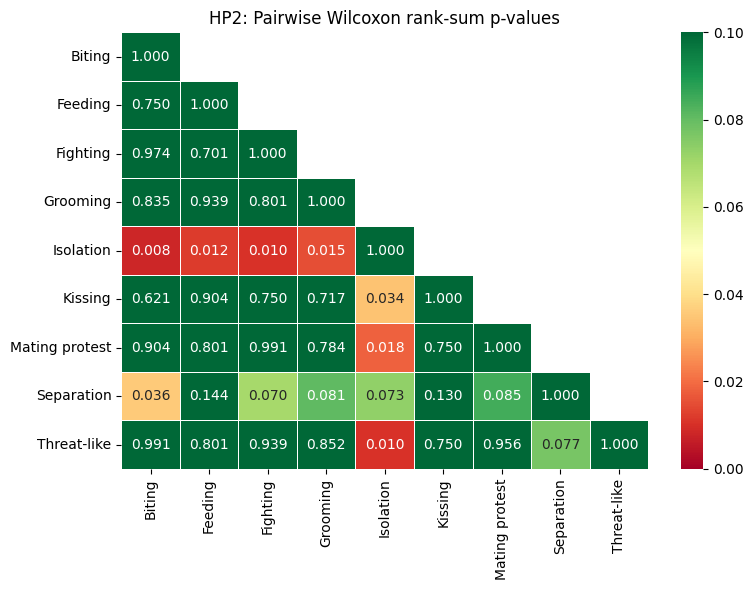


Significant pairs (p < 0.05): 8
  Biting vs Isolation: p=0.0081
  Biting vs Separation: p=0.0359
  Feeding vs Isolation: p=0.0119
  Fighting vs Isolation: p=0.0105
  Grooming vs Isolation: p=0.0152
  Isolation vs Kissing: p=0.0340
  Isolation vs Mating protest: p=0.0182
  Isolation vs Threat-like: p=0.0105


In [ ]:
# Compute syllable frequency distributions per context
contexts = sorted(seq_df['context_name'].unique())
syl_types = sorted(seg_df['syllable_id'].unique())

ctx_freq = {}
for ctx in contexts:
    ctx_seqs = seq_df[seq_df['context_name'] == ctx]['seq']
    all_syls = [s for seq in ctx_seqs for s in seq]
    counts = collections.Counter(all_syls)
    total = sum(counts.values())
    ctx_freq[ctx] = np.array([counts.get(t, 0) / total if total > 0 else 0 for t in syl_types])

# Pairwise Wilcoxon rank-sum tests
from itertools import combinations

pval_matrix = pd.DataFrame(1.0, index=contexts, columns=contexts)

for c1, c2 in combinations(contexts, 2):
    stat, pval = ranksums(ctx_freq[c1], ctx_freq[c2])
    pval_matrix.loc[c1, c2] = pval
    pval_matrix.loc[c2, c1] = pval

print('=== HP2: Wilcoxon Rank-Sum p-values ===')
print('(p < 0.05 → syllable usage differs significantly between contexts)')
print()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(pval_matrix, dtype=bool), k=1)
sns.heatmap(pval_matrix.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=0.1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('HP2: Pairwise Wilcoxon rank-sum p-values')
plt.tight_layout()
plt.show()

sig_pairs = [(c1, c2, pval_matrix.loc[c1, c2])
             for c1, c2 in combinations(contexts, 2)
             if pval_matrix.loc[c1, c2] < 0.05]
print(f'\nSignificant pairs (p < 0.05): {len(sig_pairs)}')
for c1, c2, p in sig_pairs:
    print(f'  {c1} vs {c2}: p={p:.4f}')

## 15. HP3 — Maximal Repeats + Power-Law Fitting

In [ ]:
from suffix_tree import Tree
import powerlaw

def extract_maximal_repeats(seq):
    """Extract maximal repeats from a sequence using suffix tree."""
    if len(seq) < 2:
        return []
    
    str_seq = ' '.join(str(s) for s in seq)
    try:
        tree = Tree({0: str_seq})
    except Exception:
        return []
    
    mrs = []
    tokens = str_seq.split()
    n = len(tokens)
    
    for length in range(2, n + 1):
        for start in range(n - length + 1):
            subseq = ' '.join(tokens[start:start + length])
            count = str_seq.count(subseq)
            if count >= 2:
                longer = False
                if start > 0:
                    ext_left = ' '.join(tokens[start - 1:start + length])
                    if str_seq.count(ext_left) >= 2:
                        longer = True
                if start + length < n and not longer:
                    ext_right = ' '.join(tokens[start:start + length + 1])
                    if str_seq.count(ext_right) >= 2:
                        longer = True
                if not longer:
                    mrs.append(length)
    
    return mrs if mrs else [1]


all_mr_lengths = []
mr_by_context = collections.defaultdict(list)

for _, row in tqdm(seq_df.iterrows(), total=len(seq_df), desc='Maximal repeats'):
    mr_lens = extract_maximal_repeats(row['seq'])
    all_mr_lengths.extend(mr_lens)
    mr_by_context[row['context_name']].extend(mr_lens)

all_mr_lengths = np.array(all_mr_lengths)
print(f'Total maximal repeats: {len(all_mr_lengths)}')
print(f'MR length stats: mean={all_mr_lengths.mean():.2f}, max={all_mr_lengths.max()}')

Maximal repeats:   0%|          | 0/4089 [00:00<?, ?it/s]

Total maximal repeats: 6128
MR length stats: mean=1.51, max=6


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 4/4 [00:00<00:00, 580.97it/s]

=== HP3: Power-law vs Exponential ===
Power-law alpha: 2.39
Likelihood ratio R: -961.309 (>0 → power-law preferred)
p-value: 0.0000
→ Exponential distribution — memory-less process


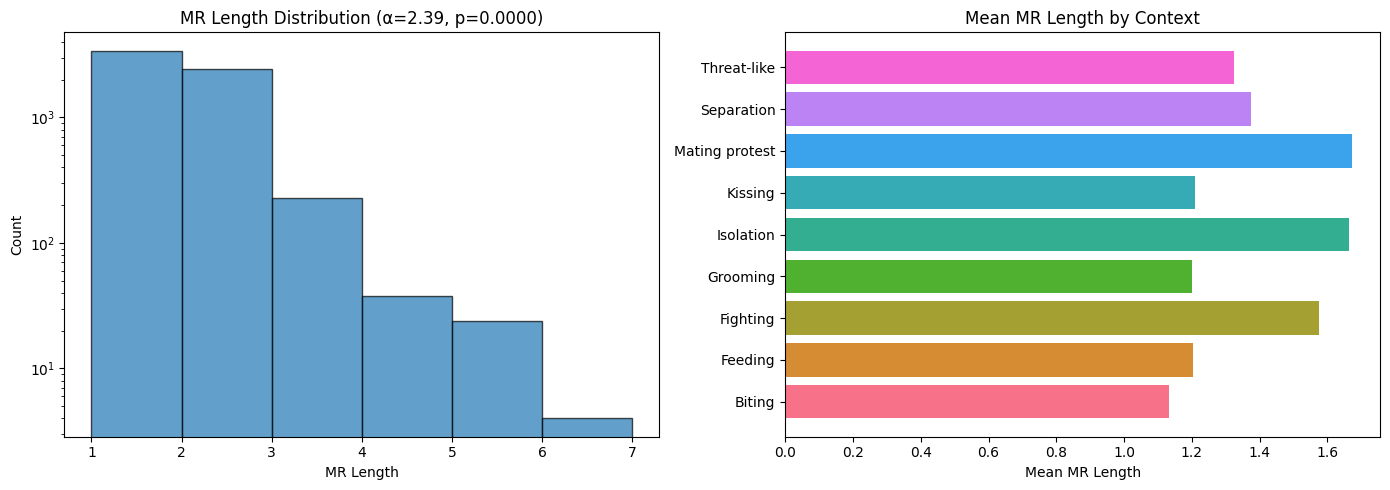

In [ ]:
if len(all_mr_lengths) > 10:
    fit = powerlaw.Fit(all_mr_lengths, discrete=True)
    R, p = fit.distribution_compare('power_law', 'exponential')
    
    print(f'=== HP3: Power-law vs Exponential ===')
    print(f'Power-law alpha: {fit.alpha:.2f}')
    print(f'Likelihood ratio R: {R:.3f} (>0 → power-law preferred)')
    print(f'p-value: {p:.4f}')
    
    if R > 0 and p < 0.05:
        print('→ Heavy-tailed (power-law) distribution — long-range dependencies exist')
    else:
        print('→ Exponential distribution — memory-less process')
    
    # Plot MR length distribution per context
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall distribution
    axes[0].hist(all_mr_lengths, bins=range(1, int(all_mr_lengths.max()) + 2),
                 edgecolor='k', alpha=0.7)
    axes[0].set_xlabel('MR Length')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'MR Length Distribution (α={fit.alpha:.2f}, p={p:.4f})')
    axes[0].set_yscale('log')
    
    # Per-context mean MR length
    ctx_mr_means = {c: np.mean(v) for c, v in mr_by_context.items() if len(v) > 0}
    ctx_names = sorted(ctx_mr_means.keys())
    axes[1].barh(ctx_names, [ctx_mr_means[c] for c in ctx_names],
                 color=sns.color_palette('husl', len(ctx_names)))
    axes[1].set_xlabel('Mean MR Length')
    axes[1].set_title('Mean MR Length by Context')
    
    plt.tight_layout()
    plt.show()
else:
    print('Not enough maximal repeats for power-law fitting.')

## 16. Transition Network Analysis

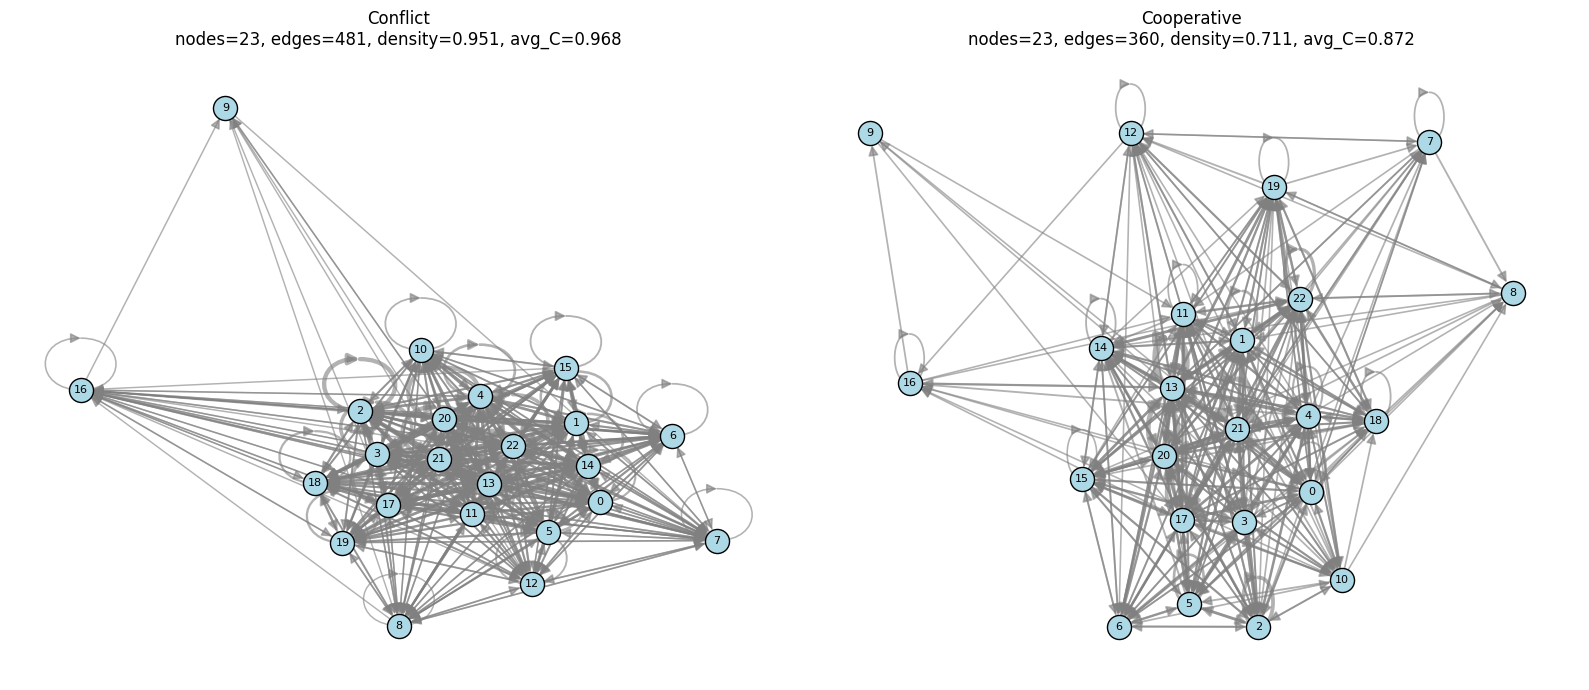

In [ ]:
def build_transition_network(sequences, min_edge_weight=2):
    G = nx.DiGraph()
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)
    
    # Remove weak edges
    edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < min_edge_weight]
    G.remove_edges_from(edges_to_remove)
    G.remove_nodes_from(list(nx.isolates(G)))
    return G


# Build networks for conflict vs cooperative contexts
conflict_ctx = {'Fighting', 'Mating protest', 'Threat-like'}
coop_ctx = {'Feeding', 'Grooming', 'Kissing'}

present_conflict = conflict_ctx & set(seq_df['context_name'])
present_coop = coop_ctx & set(seq_df['context_name'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, ctx_set, title in [(axes[0], present_conflict, 'Conflict'),
                            (axes[1], present_coop, 'Cooperative')]:
    if not ctx_set:
        ax.set_title(f'{title} — no data')
        continue
    
    seqs = seq_df[seq_df['context_name'].isin(ctx_set)]['seq'].tolist()
    G = build_transition_network(seqs)
    
    if len(G) == 0:
        ax.set_title(f'{title} — empty network')
        continue
    
    pos = nx.spring_layout(G, seed=42, k=2)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    widths = [1 + 4 * w / max_w for w in weights]
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color='lightblue', edgecolors='black')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.6,
                           edge_color='gray', arrows=True, arrowsize=15)
    
    Gu = G.to_undirected()
    density = nx.density(G)
    avg_clustering = nx.average_clustering(Gu) if len(Gu) > 2 else 0
    
    ax.set_title(f'{title}\nnodes={len(G)}, edges={G.number_of_edges()}, '
                 f'density={density:.3f}, avg_C={avg_clustering:.3f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Summary

**Key changes from previous attempts:**
1. **Spectrogram shape (21, 32)** instead of (32, 128) — this is the coarse-grained temporal dimension
2. **skimage.transform.resize** to ensure consistent shape regardless of segment duration
3. **IQR filtering** on segment duration
4. **NCA noise reassignment** after HDBSCAN
5. **Dynamic threshold segmentation** to isolate individual syllables
6. All UMAP/HDBSCAN parameters matched to Assom's code exactly